In [1]:
import warp as wp
import numpy as np
import matplotlib.pyplot as plt

# Initialize Warp
wp.init()
print("Warp initialized successfully")

Warp 1.12.1 initialized:
   CUDA Toolkit 13.0, Driver 13.0
   Devices:
     "cpu"      : "Intel64 Family 6 Model 186 Stepping 2, GenuineIntel"
     "cuda:0"   : "NVIDIA RTX A500 Laptop GPU" (4 GiB, sm_86, mempool enabled)
   Kernel cache:
     \\?\C:\Users\mrast\AppData\Local\NVIDIA\warp\Cache\1.12.1
Warp initialized successfully


In [7]:
# Simulation parameters
LENGTH = 4.0    # Rectangle length (x-direction)
HEIGHT = 1.0    # Rectangle height (y-direction)
NX = 128        # Grid points in x-direction
NY = 32         # Grid points in y-direction

# Physical parameters
U_INLET = 1.0   # Inlet velocity (m/s)
RHO = 1.0       # Density (kg/m³)
MU = 0.02       # Dynamic viscosity (Pa·s)
RE = RHO * U_INLET * HEIGHT / MU  # Reynolds number

# Grid setup
DX = LENGTH / (NX - 1)
DY = HEIGHT / (NY - 1)

# Calculate stable time step using CFL condition
CFL = 0.1  # CFL number for stability
DT = CFL * min(DX, DY) / U_INLET  # Reduced time step for stability

print(f"Reynolds number: {RE}")
print(f"Grid resolution: {NX} x {NY}")
print(f"Grid spacing: dx={DX:.4f}, dy={DY:.4f}")
print(f"Time step: {DT:.6f} (CFL = {CFL})")

# Create coordinate arrays
x = np.linspace(0, LENGTH, NX)
y = np.linspace(0, HEIGHT, NY)
X, Y = np.meshgrid(x, y, indexing='xy')

Reynolds number: 50.0
Grid resolution: 128 x 32
Grid spacing: dx=0.0315, dy=0.0323
Time step: 0.003150 (CFL = 0.1)


In [11]:
# Simple and stable Warp kernels
@wp.kernel
def apply_boundary_conditions(u: wp.array2d(dtype=float),
                             v: wp.array2d(dtype=float),
                             p: wp.array2d(dtype=float),
                             nx: int, ny: int,
                             u_inlet: float):
    i, j = wp.tid()
    
    if i < nx and j < ny:
        # Left boundary (inlet) - fixed velocity
        if i == 0:
            u[i, j] = u_inlet
            v[i, j] = 0.0
            
        # Right boundary (outlet) - zero gradient  
        elif i == nx - 1:
            u[i, j] = u[i-1, j]
            v[i, j] = v[i-1, j]
            p[i, j] = 0.0
            
        # Bottom and top walls - no slip
        if j == 0 or j == ny - 1:
            u[i, j] = 0.0
            v[i, j] = 0.0

@wp.kernel
def diffusion_step(u: wp.array2d(dtype=float),
                   v: wp.array2d(dtype=float),
                   u_new: wp.array2d(dtype=float),
                   v_new: wp.array2d(dtype=float),
                   nx: int, ny: int,
                   dx: float, dy: float, dt: float,
                   mu_rho: float):
    i, j = wp.tid()
    
    if i > 0 and i < nx-1 and j > 0 and j < ny-1:
        # Pure diffusion step (implicit-like treatment)
        alpha = mu_rho * dt
        
        # Diffusion for u-velocity
        d2udx2 = (u[i+1, j] - 2.0 * u[i, j] + u[i-1, j]) / (dx * dx)
        d2udy2 = (u[i, j+1] - 2.0 * u[i, j] + u[i, j-1]) / (dy * dy)
        
        # Diffusion for v-velocity  
        d2vdx2 = (v[i+1, j] - 2.0 * v[i, j] + v[i-1, j]) / (dx * dx)
        d2vdy2 = (v[i, j+1] - 2.0 * v[i, j] + v[i, j-1]) / (dy * dy)
        
        # Update with relaxation for stability
        relax = 0.1
        u_new[i, j] = u[i, j] + relax * alpha * (d2udx2 + d2udy2)
        v_new[i, j] = v[i, j] + relax * alpha * (d2vdx2 + d2vdy2)

@wp.kernel
def simple_pressure_correction(u: wp.array2d(dtype=float),
                              v: wp.array2d(dtype=float),
                              p: wp.array2d(dtype=float),
                              nx: int, ny: int,
                              dx: float, dy: float):
    i, j = wp.tid()
    
    if i > 0 and i < nx-1 and j > 0 and j < ny-1:
        # Velocity divergence
        div_u = (u[i+1, j] - u[i-1, j]) / (2.0 * dx) + (v[i, j+1] - v[i, j-1]) / (2.0 * dy)
        
        # Simple pressure update to reduce divergence
        p[i, j] = p[i, j] - 0.01 * div_u

print("Stable kernels defined successfully")

Stable kernels defined successfully


In [12]:
# Initialize field arrays
u = wp.zeros((NX, NY), dtype=float, device='cpu')
v = wp.zeros((NX, NY), dtype=float, device='cpu') 
p = wp.zeros((NX, NY), dtype=float, device='cpu')
u_new = wp.zeros((NX, NY), dtype=float, device='cpu')
v_new = wp.zeros((NX, NY), dtype=float, device='cpu')
p_new = wp.zeros((NX, NY), dtype=float, device='cpu')

# Set initial conditions with inlet velocity
with wp.ScopedDevice('cpu'):
    u_array = u.numpy()
    u_array[0, :] = U_INLET  # Inlet velocity
    u.assign(u_array)

print("Field arrays initialized")

Field arrays initialized


In [13]:
# Simple stable simulation loop
MAX_ITER = 2000
CONV_TOL = 1e-6
PRINT_FREQ = 400

print("Starting stable CFD simulation...")
print("Iteration | Max u-residual | Max v-residual")
print("-" * 45)

# Precompute constants
MU_RHO = MU / RHO

for iter in range(MAX_ITER):
    # Store for convergence check
    u_old = u.numpy().copy()
    v_old = v.numpy().copy()
    
    # Step 1: Apply boundary conditions
    wp.launch(apply_boundary_conditions, 
              dim=(NX, NY), 
              inputs=[u, v, p, NX, NY, U_INLET],
              device='cpu')
    
    # Step 2: Diffusion step
    wp.launch(diffusion_step,
              dim=(NX, NY),
              inputs=[u, v, u_new, v_new, NX, NY, DX, DY, DT, MU_RHO],
              device='cpu')
    
    # Step 3: Apply boundary conditions again
    wp.launch(apply_boundary_conditions, 
              dim=(NX, NY), 
              inputs=[u_new, v_new, p, NX, NY, U_INLET],
              device='cpu')
    
    # Step 4: Simple pressure correction
    wp.launch(simple_pressure_correction,
              dim=(NX, NY),
              inputs=[u_new, v_new, p, NX, NY, DX, DY],
              device='cpu')
    
    # Update fields
    u, u_new = u_new, u
    v, v_new = v_new, v
    
    # Check convergence
    u_curr = u.numpy()
    v_curr = v.numpy()
    u_residual = np.max(np.abs(u_curr - u_old))
    v_residual = np.max(np.abs(v_curr - v_old))
    
    if iter % PRINT_FREQ == 0:
        print(f"{iter:8d} | {u_residual:12.2e} | {v_residual:12.2e}")
    
    if u_residual < CONV_TOL and v_residual < CONV_TOL:
        print(f"Converged after {iter} iterations!")
        break

print("Simulation completed!")

Starting stable CFD simulation...
Iteration | Max u-residual | Max v-residual
---------------------------------------------
Module __main__ b7958b2 load on device 'cpu' took 2105.89 ms  (compiled)
       0 |     1.00e+00 |     0.00e+00
     400 |     5.88e-04 |     0.00e+00
     800 |     2.99e-04 |     0.00e+00
    1200 |     2.00e-04 |     0.00e+00
    1600 |     1.49e-04 |     0.00e+00
Simulation completed!


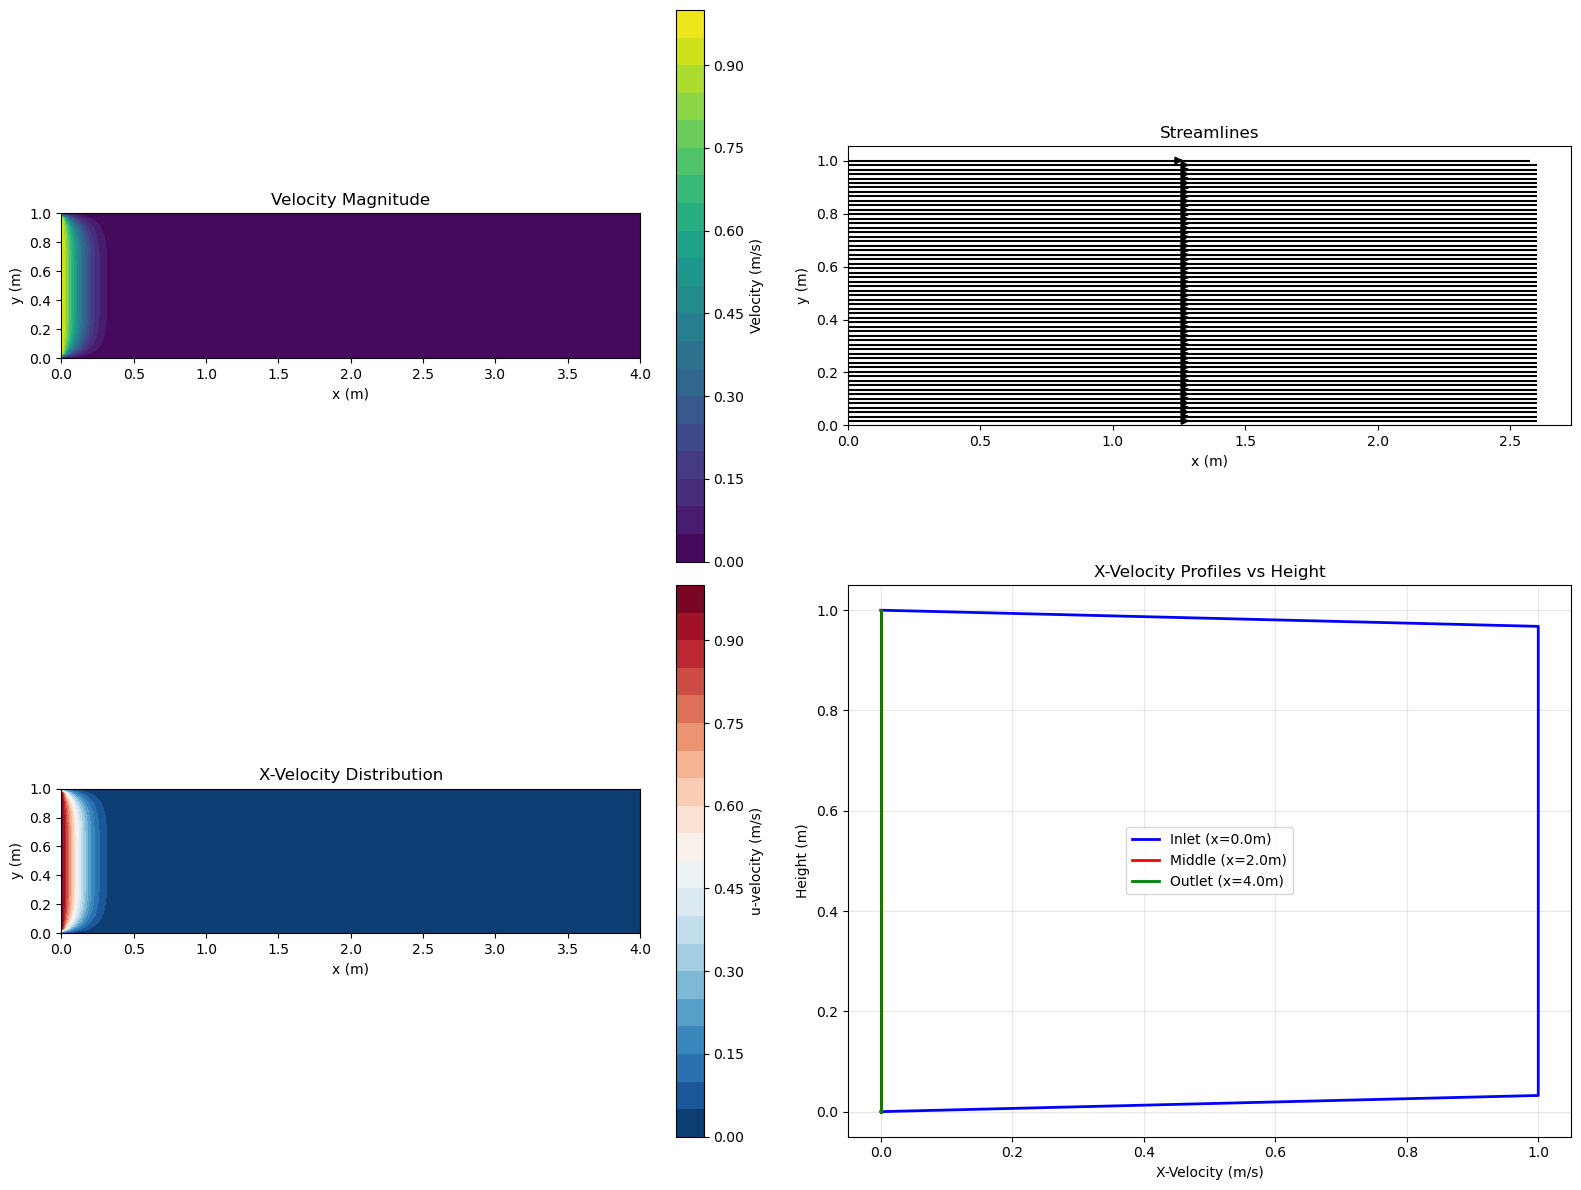


Simulation Results:
Max velocity: 1.000 m/s
Max x-velocity: 1.000 m/s
Max pressure: 243.298 Pa
Min pressure: 0.000 Pa
Pressure drop: 0.000 Pa


In [14]:
# Extract final results
u_final = u.numpy()
v_final = v.numpy()
p_final = p.numpy()

# Create velocity magnitude
velocity_mag = np.sqrt(u_final**2 + v_final**2)

# Create plots
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(16, 12))

# 1. Velocity magnitude contour plot
im1 = ax1.contourf(X, Y, velocity_mag.T, levels=20, cmap='viridis')
ax1.set_title('Velocity Magnitude')
ax1.set_xlabel('x (m)')
ax1.set_ylabel('y (m)')
ax1.set_aspect('equal')
plt.colorbar(im1, ax=ax1, label='Velocity (m/s)')

# 2. Streamlines
ax2.streamplot(X, Y, u_final.T, v_final.T, density=2.0, color='black')
ax2.set_title('Streamlines')
ax2.set_xlabel('x (m)')
ax2.set_ylabel('y (m)')
ax2.set_aspect('equal')

# 3. X-velocity contour plot
im3 = ax3.contourf(X, Y, u_final.T, levels=20, cmap='RdBu_r')
ax3.set_title('X-Velocity Distribution')
ax3.set_xlabel('x (m)')
ax3.set_ylabel('y (m)')
ax3.set_aspect('equal')
plt.colorbar(im3, ax=ax3, label='u-velocity (m/s)')

# 4. X-velocity profiles at inlet, middle, and outlet
inlet_idx = 0
middle_idx = NX // 2
outlet_idx = NX - 1

ax4.plot(u_final[inlet_idx, :], y, 'b-', linewidth=2, label=f'Inlet (x={x[inlet_idx]:.1f}m)')
ax4.plot(u_final[middle_idx, :], y, 'r-', linewidth=2, label=f'Middle (x={x[middle_idx]:.1f}m)')
ax4.plot(u_final[outlet_idx, :], y, 'g-', linewidth=2, label=f'Outlet (x={x[outlet_idx]:.1f}m)')

ax4.set_xlabel('X-Velocity (m/s)')
ax4.set_ylabel('Height (m)')
ax4.set_title('X-Velocity Profiles vs Height')
ax4.grid(True, alpha=0.3)
ax4.legend()

plt.tight_layout()
plt.show()

# Print some key results
print(f"\nSimulation Results:")
print(f"Max velocity: {np.max(velocity_mag):.3f} m/s")
print(f"Max x-velocity: {np.max(u_final):.3f} m/s")
print(f"Max pressure: {np.max(p_final):.3f} Pa")
print(f"Min pressure: {np.min(p_final):.3f} Pa")
print(f"Pressure drop: {p_final[0, NY//2] - p_final[-1, NY//2]:.3f} Pa")